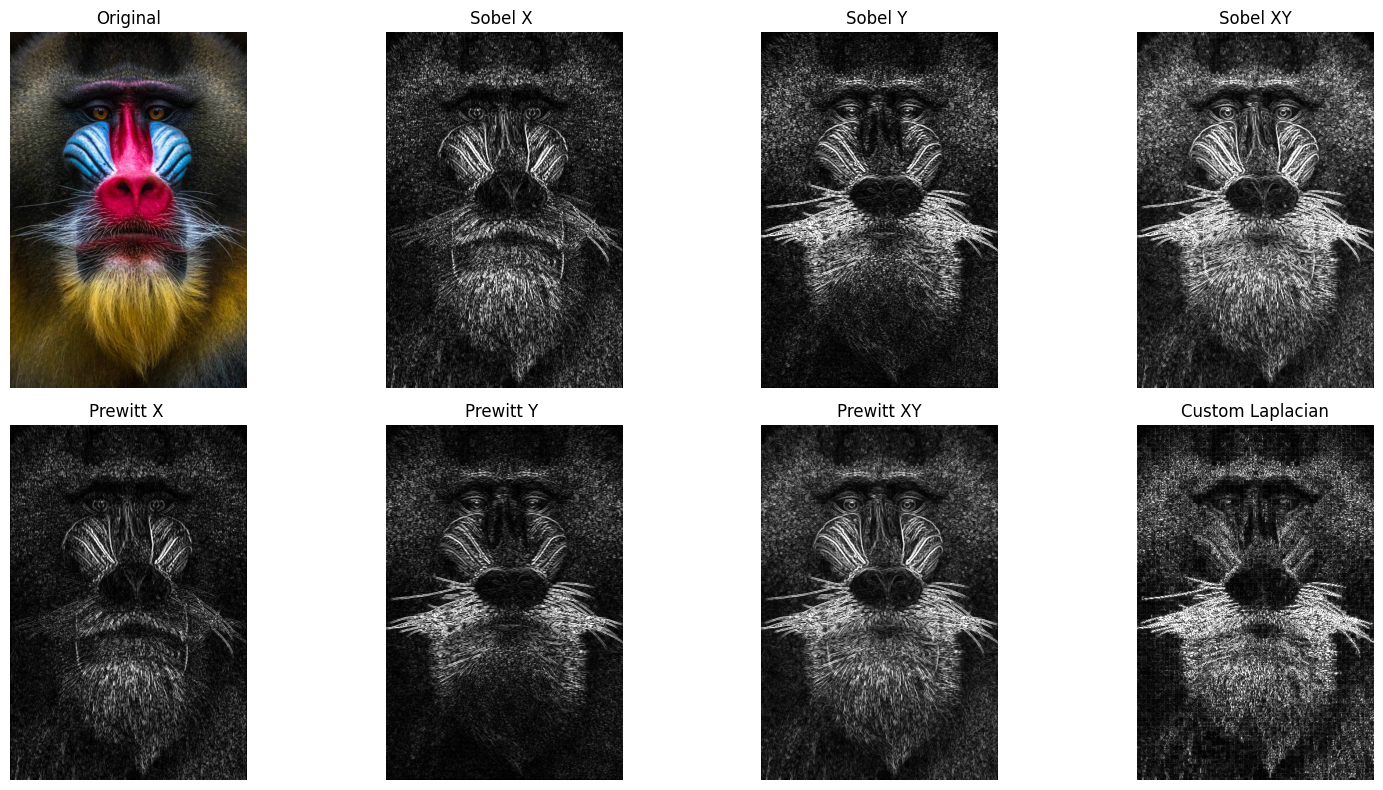

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('../input/lab_image.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#1 
sobel_x_64f = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_64f = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x_64f, sobel_y_64f)
sobel_x = cv2.convertScaleAbs(sobel_x_64f)
sobel_y = cv2.convertScaleAbs(sobel_y_64f)
sobel_combined = cv2.convertScaleAbs(sobel_mag)

kernelx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

kernely = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)


prewitt_x_64f = cv2.filter2D(gray, cv2.CV_64F, kernelx)
prewitt_y_64f = cv2.filter2D(gray, cv2.CV_64F, kernely)

prewitt_mag = cv2.magnitude(prewitt_x_64f, prewitt_y_64f)

prewitt_x = cv2.convertScaleAbs(prewitt_x_64f)
prewitt_y = cv2.convertScaleAbs(prewitt_y_64f)
prewitt_combined = cv2.convertScaleAbs(prewitt_mag)

# --- 3 custom.
custom_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

custom_result_64f = cv2.filter2D(gray, cv2.CV_64F, custom_kernel)
custom_result = cv2.convertScaleAbs(custom_result_64f)

edge_images = [
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB),  
    sobel_x,                              
    sobel_y,                              
    sobel_combined,                       
    prewitt_x,                         
    prewitt_y,                             
    prewitt_combined,                     
    custom_result                          
]

edge_titles = [
    "Original", "Sobel X ", "Sobel Y ", "Sobel XY",
    "Prewitt X ", "Prewitt Y ", "Prewitt XY", "Custom Laplacian"
]


plt.figure(figsize=(16, 8))
for i, (img_show, title) in enumerate(zip(edge_images, edge_titles)):
    plt.subplot(2, 4, i + 1)
    if i == 0:  
        plt.imshow(img_show)
    else:       
        plt.imshow(img_show, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()